In [28]:
#importing Libraries
import pandas as pd
import numpy as np


In [29]:
#Importing preprocessor objects
import joblib
preprocessor_cls = joblib.load("preprocessor.pkl")

X_train_cls_pp = joblib.load("X_train_cls_preprocessed.pkl")
X_test_cls_pp = joblib.load("X_test_cls_preprocessed.pkl")
y_train_cls = joblib.load("y_train_cls.pkl")
y_test_cls = joblib.load("y_test_cls.pkl")
X_train_reg_pp = joblib.load("X_train_reg_preprocessed.pkl")
X_test_reg_pp = joblib.load("X_test_reg_preprocessed.pkl")
y_train_reg = joblib.load("y_train_reg.pkl")
y_test_reg = joblib.load("y_test_reg.pkl")


c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.9.0 when using version 1.8.0. This might lead to breaki

In [30]:
#Importing models

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, DBSCAN
from xgboost import XGBClassifier, XGBRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

import numpy as np
import mlflow
import mlflow.sklearn

In [ ]:
#SET MLflow TRACKING AND EXPERIMENT

mlflow.set_tracking_uri(r"file:///e:/Laptop/Clickstream/mlruns")
mlflow.set_experiment("Clickstream_Customer_Conversion_Project")
print('mlflow tracking uri set to', mlflow.get_tracking_uri())

Traceback (most recent call last):
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ADM

mlflow tracking uri set to file:///e:/Laptop/Clickstream/Notebooks/mlruns


In [32]:
cls_results = []

In [33]:
def evaluate_classification(model,
                            X_train,
                            X_test,
                            y_train,
                            y_test,
                            model_name):

    with mlflow.start_run(run_name=model_name):

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        try:
            y_prob = model.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_prob)
        except:
            roc_auc = 0

        mlflow.log_param("model", model_name)

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1", f1)
        mlflow.log_metric("roc_auc", roc_auc)

        mlflow.sklearn.log_model(model, model_name)

        cls_results.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ROC_AUC": roc_auc,
            "Model_Object": model
        })

        print(f"\n{model_name}")
        print("Accuracy:", accuracy)
        print("F1:", f1)
        print("ROC_AUC:", roc_auc)

        

In [34]:
models_cls = {
    "LogisticRegression": LogisticRegression(max_iter=1000),

    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(eval_metric="logloss"),

    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [60]:
#Model Training


for name, model in models_cls.items():

    evaluate_classification(
        model,
        X_train_cls_pp,
        X_test_cls_pp,
        y_train_cls,
        y_test_cls,
        name
    )
    



2026/06/08 17:40:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:40:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



LogisticRegression
Accuracy: 1.0
F1: 1.0
ROC_AUC: 1.0


2026/06/08 17:40:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:40:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



RandomForest
Accuracy: 1.0
F1: 1.0
ROC_AUC: 1.0


2026/06/08 17:40:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:40:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



XGBoost
Accuracy: 1.0
F1: 1.0
ROC_AUC: 1.0


2026/06/08 17:46:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:46:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



KNN
Accuracy: 0.9996600694969029
F1: 0.9996678108736574
ROC_AUC: 0.9999599889510584


In [36]:
#results df

cls_results_df = pd.DataFrame(cls_results)

cls_results_df.sort_values(
    by="F1",
    ascending=False,
    inplace=True
)

print(cls_results_df[
    ["Model",
     "Accuracy",
     "Precision",
     "Recall",
     "F1",
     "ROC_AUC"]
])

                Model  Accuracy  Precision    Recall        F1  ROC_AUC
0  LogisticRegression   1.00000    1.00000  1.000000  1.000000  1.00000
1        RandomForest   1.00000    1.00000  1.000000  1.000000  1.00000
2             XGBoost   1.00000    1.00000  1.000000  1.000000  1.00000
3                 KNN   0.99966    0.99941  0.999926  0.999668  0.99996


In [37]:
best_row = cls_results_df.iloc[0]

best_model_name = best_row["Model"]

best_model_cls = best_row["Model_Object"]

print("Best Model:", best_model_name)

Best Model: LogisticRegression


In [38]:
import joblib

joblib.dump(best_model_cls, "best_classifier.pkl")

['best_classifier.pkl']

In [39]:
results_reg = []

In [40]:
#Regression Models

models_reg = {
    "LinearRegression": LinearRegression(),

    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "XGBoostRegressor": XGBRegressor(
        eval_metric="rmse",
        random_state=42
    ),

    "KNNRegressor": KNeighborsRegressor(n_neighbors=5)
}

In [41]:
#Regression Model Evaluation function
def evaluate_regression(model,
                        X_train,
                        X_test,
                        y_train,
                        y_test,
                        model_name):

    with mlflow.start_run(run_name=model_name):

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = mse ** 0.5

        mlflow.log_param("model", model_name)

        mlflow.log_metric("r2_score", r2)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("rmse", rmse)

        mlflow.sklearn.log_model(model, model_name)

        results_reg.append({
            "Model": model_name,
            "R2": r2,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "Model_Object": model
        })

        print(f"\n{model_name}")
        print("R2:", r2)
        print("MAE:", mae)
        print("RMSE:", rmse)

In [66]:
import mlflow
mlflow.set_tracking_uri(r"file:///e:/Laptop/Clickstream/mlruns")
mlflow.set_experiment("Clickstream_Customer_Conversion_Project")
print('mlflow tracking uri set to', mlflow.get_tracking_uri())
# quick test run to confirm writes
with mlflow.start_run(run_name='test_tracking_uri'):
    mlflow.log_param('test_param','ok')
    print('created run id', mlflow.active_run().info.run_id)

runs = mlflow.search_runs(experiment_names=['Clickstream_Customer_Conversion_Project'])
print('Total runs:', len(runs))
print('Available columns:', list(runs.columns))
print('Sample runs:')
print(runs[['tags.mlflow.runName','status']].head(20).to_string(index=False))
print('Unique run names:', runs['tags.mlflow.runName'].unique())

mlflow tracking uri set to file:///e:/Laptop/Clickstream/mlruns
created run id c4718fc4b5a24a68835dd510c172ac0b
Total runs: 22
Available columns: ['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time', 'metrics.mae', 'metrics.mse', 'metrics.rmse', 'metrics.r2_score', 'metrics.roc_auc', 'metrics.precision', 'metrics.recall', 'metrics.f1', 'metrics.accuracy', 'metrics.calinski_harabasz_score', 'metrics.davies_bouldin_index', 'metrics.silhouette_score', 'params.test_param', 'params.model', 'params.min_samples', 'params.eps', 'params.n_clusters', 'tags.mlflow.source.type', 'tags.mlflow.source.name', 'tags.mlflow.user', 'tags.mlflow.runName']
Sample runs:
  tags.mlflow.runName   status
    test_tracking_uri FINISHED
    test_tracking_uri FINISHED
         KNNRegressor FINISHED
     XGBoostRegressor FINISHED
RandomForestRegressor FINISHED
     LinearRegression FINISHED
                  KNN FINISHED
              XGBoost FINISHED
         RandomForest FINISHED
   Logi

c:\Users\ADMIN\anaconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [61]:
#Train Regression models

for name, model in models_reg.items():
    evaluate_regression(
        model,
        X_train_reg_pp,
        X_test_reg_pp,
        y_train_reg,
        y_test_reg,
        name
    )

2026/06/08 17:46:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:46:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



LinearRegression
R2: 0.3359347728635662
MAE: 8.723731332267853
RMSE: 10.259585760141269


2026/06/08 17:48:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:48:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



RandomForestRegressor
R2: 0.9999850134721163
MAE: 0.00032029007402930947
RMSE: 0.04873881539080268


2026/06/08 17:48:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:48:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



XGBoostRegressor
R2: 0.9999976754188538
MAE: 0.01452119741588831
RMSE: 0.01925863128235951


2026/06/08 17:50:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:50:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



KNNRegressor
R2: 0.965890669208722
MAE: 0.4689001359722012
RMSE: 2.3252039696613243


In [44]:
reg_results_df = pd.DataFrame(results_reg)

reg_results_df.sort_values(
    by="R2",
    ascending=False,
    inplace=True
)

print(
    reg_results_df[
        ["Model", "R2", "MAE", "RMSE"]
    ]
)

                   Model        R2       MAE       RMSE
2       XGBoostRegressor  0.999998  0.014521   0.019259
1  RandomForestRegressor  0.999985  0.000320   0.048739
3           KNNRegressor  0.965891  0.468900   2.325204
0       LinearRegression  0.335935  8.723731  10.259586


In [45]:
best_row = reg_results_df.iloc[0]

best_model_name = best_row["Model"]

best_model_reg = best_row["Model_Object"]

print("Best Model:", best_model_name)

Best Model: XGBoostRegressor


In [46]:

train_df_fe=pd.read_csv("E:\\Laptop\\Clickstream\\artifacts\\feature_engineered_data.csv")

train_df_fe.columns

Index(['month', 'day', 'order', 'page1_main_category', 'location',
       'model_photography', 'price', 'price_2', 'page',
       'page2_clothing_model_freq', 'country_grouped', 'colour_grouped',
       'day_grouped'],
      dtype='object')

In [47]:
joblib.dump(
    best_model,
    "best_regression_model.pkl"
)



['best_regression_model.pkl']

##Clustering


In [48]:
#Clustering Features


cluster_features = [
    "day_grouped",
    "month",
    "order",
    "price",
    "page",
    "country_grouped",
    "page1_main_category",
    "colour_grouped",
    "location",
    "model_photography",
    "page2_clothing_model_freq"
]

X_cluster = train_df_fe[cluster_features]

In [49]:
# 
cat_features = [
    "country_grouped",
    "page1_main_category",
    "colour_grouped",
    "location",
    "model_photography",
    "page",
    "day_grouped",
    "month"
]

num_features = ["order", "price","page2_clothing_model_freq"]


In [50]:


from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor_cluster = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [51]:
#Processed Cluster data

X_cluster_scaled = preprocessor_cluster.fit_transform(X_cluster)

In [52]:
from sklearn.utils import resample

sample_size = 50000

idx = np.random.choice(
    X_cluster_scaled.shape[0],
    sample_size,
    replace=False
)
X_sample = X_cluster_scaled[idx].toarray()




In [53]:
#Kmeans clustering


from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

with mlflow.start_run(run_name="KMeans_Clustering"):

    kmeans = KMeans(n_clusters=4, random_state=42)
    labels = kmeans.fit_predict(X_sample)

    sil = silhouette_score(X_sample, labels)
    db = davies_bouldin_score(X_sample, labels)
    ch = calinski_harabasz_score(X_sample, labels)

    mlflow.log_param("model", "KMeans")
    mlflow.log_param("n_clusters", 4)

    mlflow.log_metric("silhouette_score", sil)
    mlflow.log_metric("davies_bouldin_index", db)
    mlflow.log_metric("calinski_harabasz_score", ch)

    mlflow.sklearn.log_model(kmeans, "kmeans_model")

    print("Silhouette:", sil)
    print("DB Index:", db)
    print("Calinski:", ch)

2026/06/08 17:22:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:22:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Silhouette: 0.10656841790711952
DB Index: 2.370035781398406
Calinski: 5604.061721815638


In [54]:
#DBSCAN

with mlflow.start_run(run_name="DBSCAN_Clustering"):

    dbscan = DBSCAN(eps=1.5, min_samples=5)
    labels = dbscan.fit_predict(X_sample)

    mask = labels != -1

    if len(set(labels)) > 1 and len(set(labels)) < len(labels):
        sil = silhouette_score(X_sample[mask], labels[mask])
        db = davies_bouldin_score(X_sample[mask], labels[mask])
        ch = calinski_harabasz_score(X_sample[mask], labels[mask])
    else:
        sil, db, ch = -1, -1, -1

    mlflow.log_param("model", "DBSCAN")
    mlflow.log_param("eps", 1.5)
    mlflow.log_param("min_samples", 5)

    mlflow.log_metric("silhouette_score", sil)
    mlflow.log_metric("davies_bouldin_index", db)
    mlflow.log_metric("calinski_harabasz_score", ch)

    mlflow.sklearn.log_model(dbscan, "dbscan_model")

  
    print("Silhouette:", sil)
    print("DB Index:", db)
    print("Calinski:", ch)

2026/06/08 17:23:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:23:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/08 17:23:06 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Silhouette: 0.20615346447849123
DB Index: 1.731015874923425
Calinski: 664.7658789643383


In [55]:
train_df_fe["customer_segment"] = dbscan.fit_predict(X_cluster_scaled)

In [56]:

train_df_fe.groupby("customer_segment").mean(numeric_only=True)

,month,day,order,page1_main_category,location,model_photography,price,price_2,page,page2_clothing_model_freq
customer_segment,,,,,,,,,,
-1,6.119577,13.583982,79.783092,2.810345,3.230256,1.343159,41.838154,1.501112,2.307564,609.745273
0,5.520325,14.000000,10.382114,3.000000,1.547425,2.000000,45.262873,1.000000,2.000000,196.802168
1,5.451342,13.986018,8.463087,2.000000,3.000000,1.000000,57.000000,1.000000,2.000000,925.302013
2,5.485642,14.981194,10.044981,3.000000,5.672427,1.000000,46.443456,1.131893,1.806353,588.241169
3,5.686333,14.191002,6.461800,2.000000,4.000000,1.000000,40.646435,2.000000,1.000000,1186.629457
...,...,...,...,...,...,...,...,...,...,...
160,5.600000,16.600000,72.600000,3.000000,1.000000,1.000000,43.000000,1.000000,1.000000,882.000000
161,4.000000,27.200000,68.400000,3.000000,3.600000,1.000000,55.400000,1.000000,3.000000,327.000000
162,6.000000,22.750000,61.250000,1.000000,3.000000,1.000000,62.000000,1.000000,3.000000,200.000000


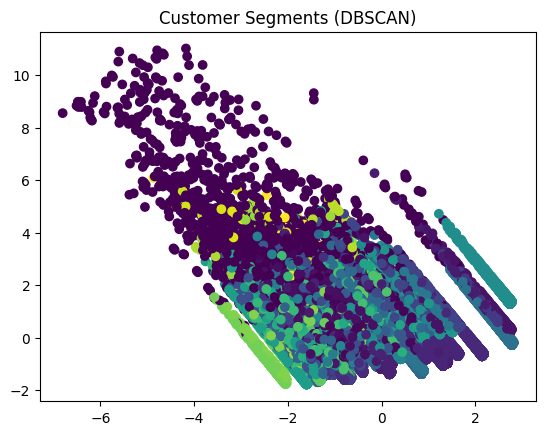

In [57]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
components = pca.fit_transform(X_cluster_scaled)

plt.scatter(components[:,0], components[:,1], c=dbscan.labels_)
plt.title("Customer Segments (DBSCAN)")
plt.show()

In [58]:
import joblib

joblib.dump(dbscan, "dbscan_model.pkl")
joblib.dump(preprocessor_cluster, "cluster_preprocessor.pkl")

['cluster_preprocessor.pkl']